Note: you may need to restart the kernel to use updated packages.
All dependencies imported successfully.
Loading dataset from: C:\Users\HP/Downloads/gtex_integrin_7_organs.xlsx
Full Dataset Shape: (1987, 29)
Liver vs Lung Dataset Shape: (398, 28)

=== MODEL 1: ITGA10 BINARY LOGISTIC REGRESSION ===
Test Accuracy: 1.0000
AUROC Score: 1.0000
Coefficient (a): 1.6320
Intercept (b): -2.6081

=== THRESHOLD OPTIMIZATION RESULTS ===
Optimal Probability Threshold (p_thresh): 0.612
Max Test Accuracy at Threshold: 1.000
Calculated Biological ITGA10 Expression Cutoff: 1.876
Figure 1 successfully saved to: fig1_roc_threshold_itga10.png


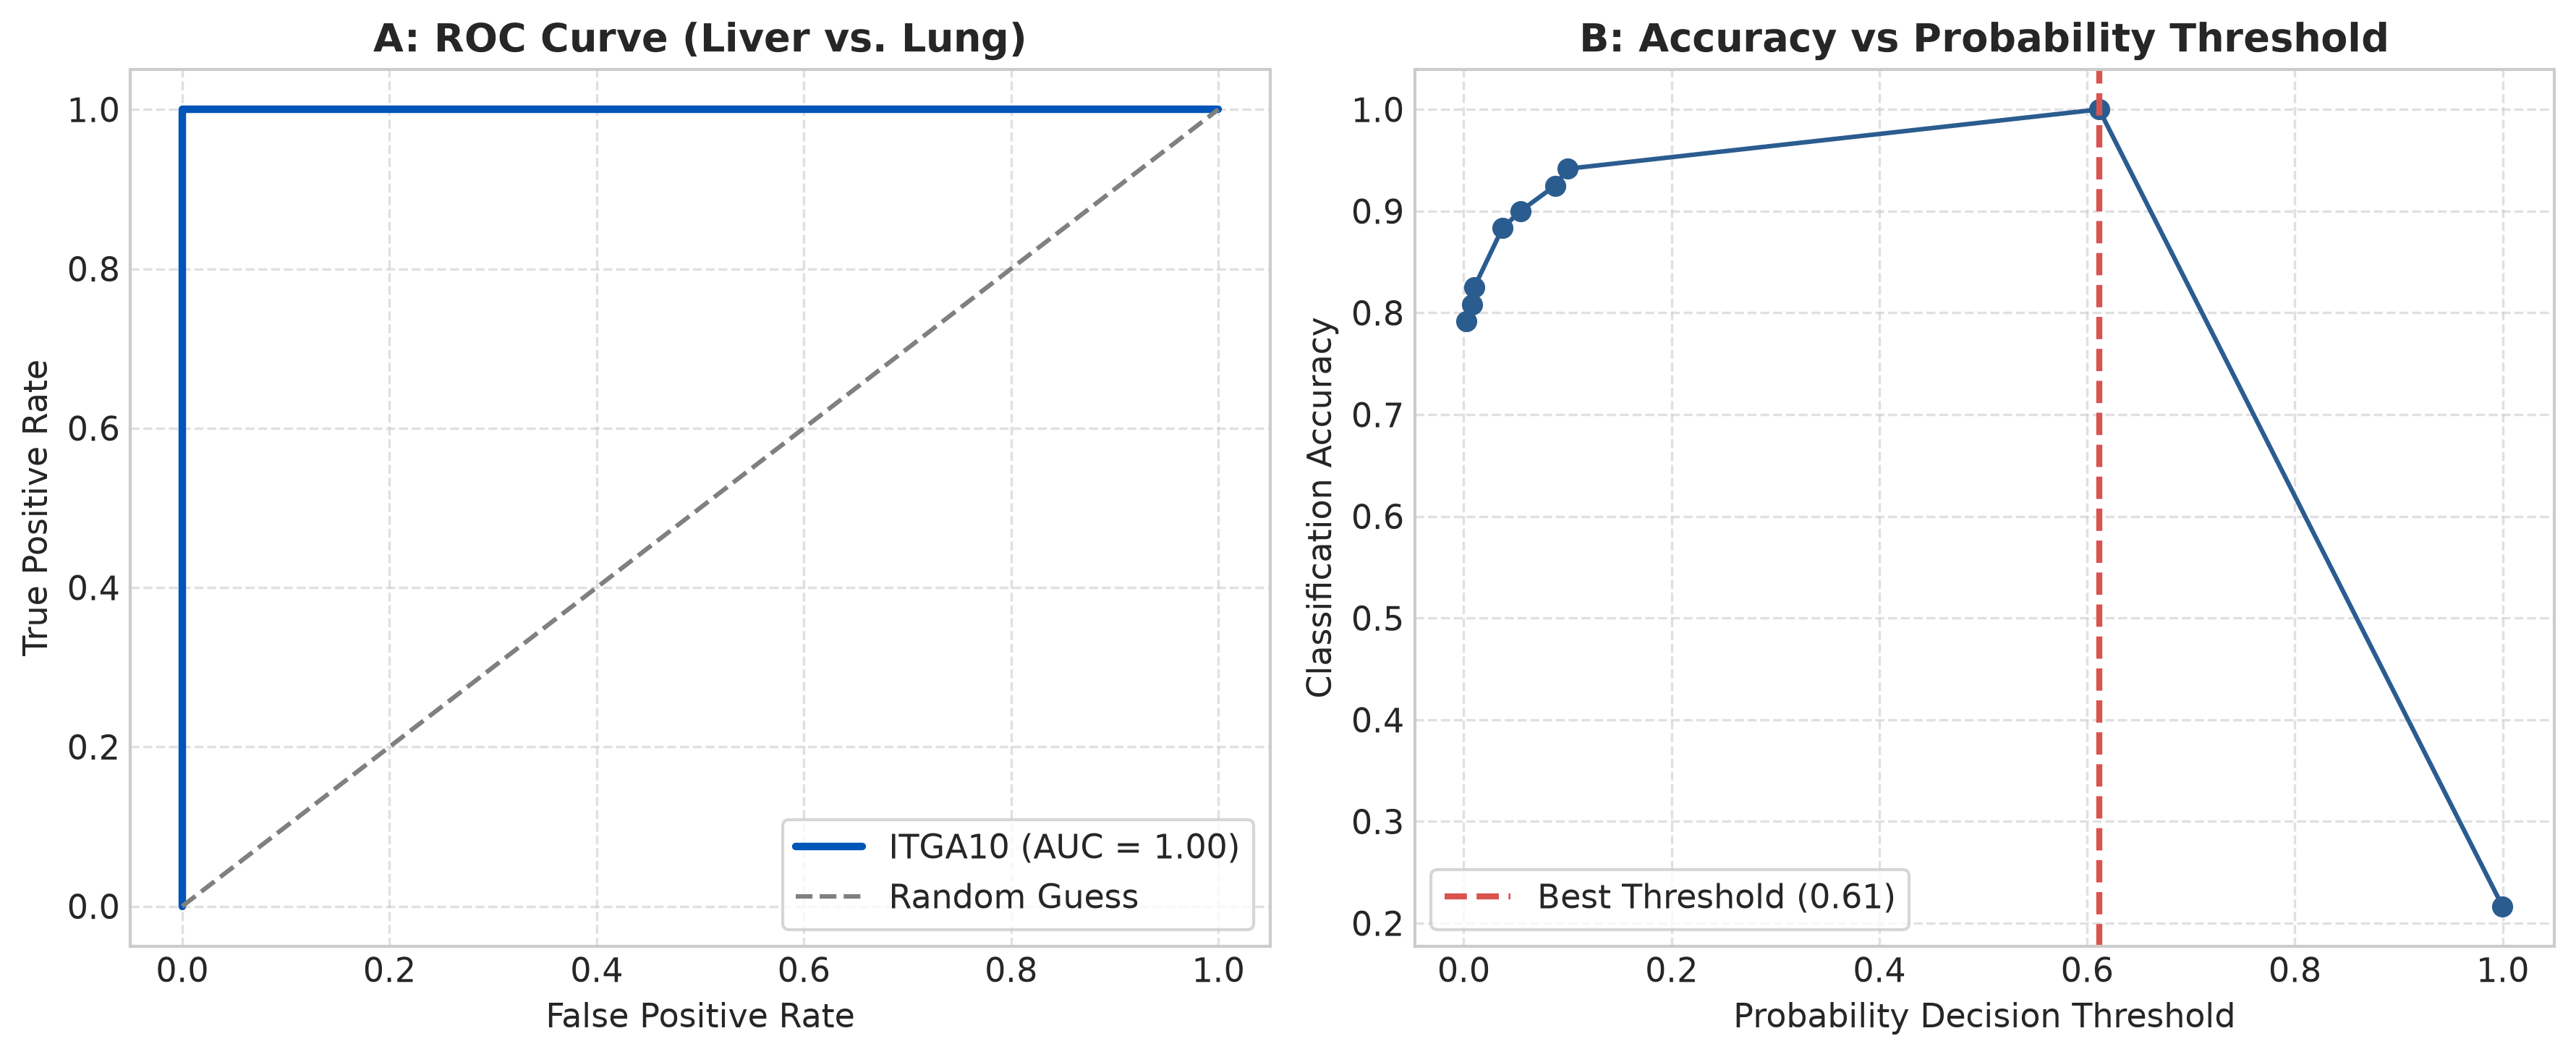


=== MODEL 2: 2D KNN (ITGA10 + ITGB1) RESULTS ===
KNN Test Accuracy: 0.9917
Figure 2 successfully saved to: fig2_knn_decision_boundary.png


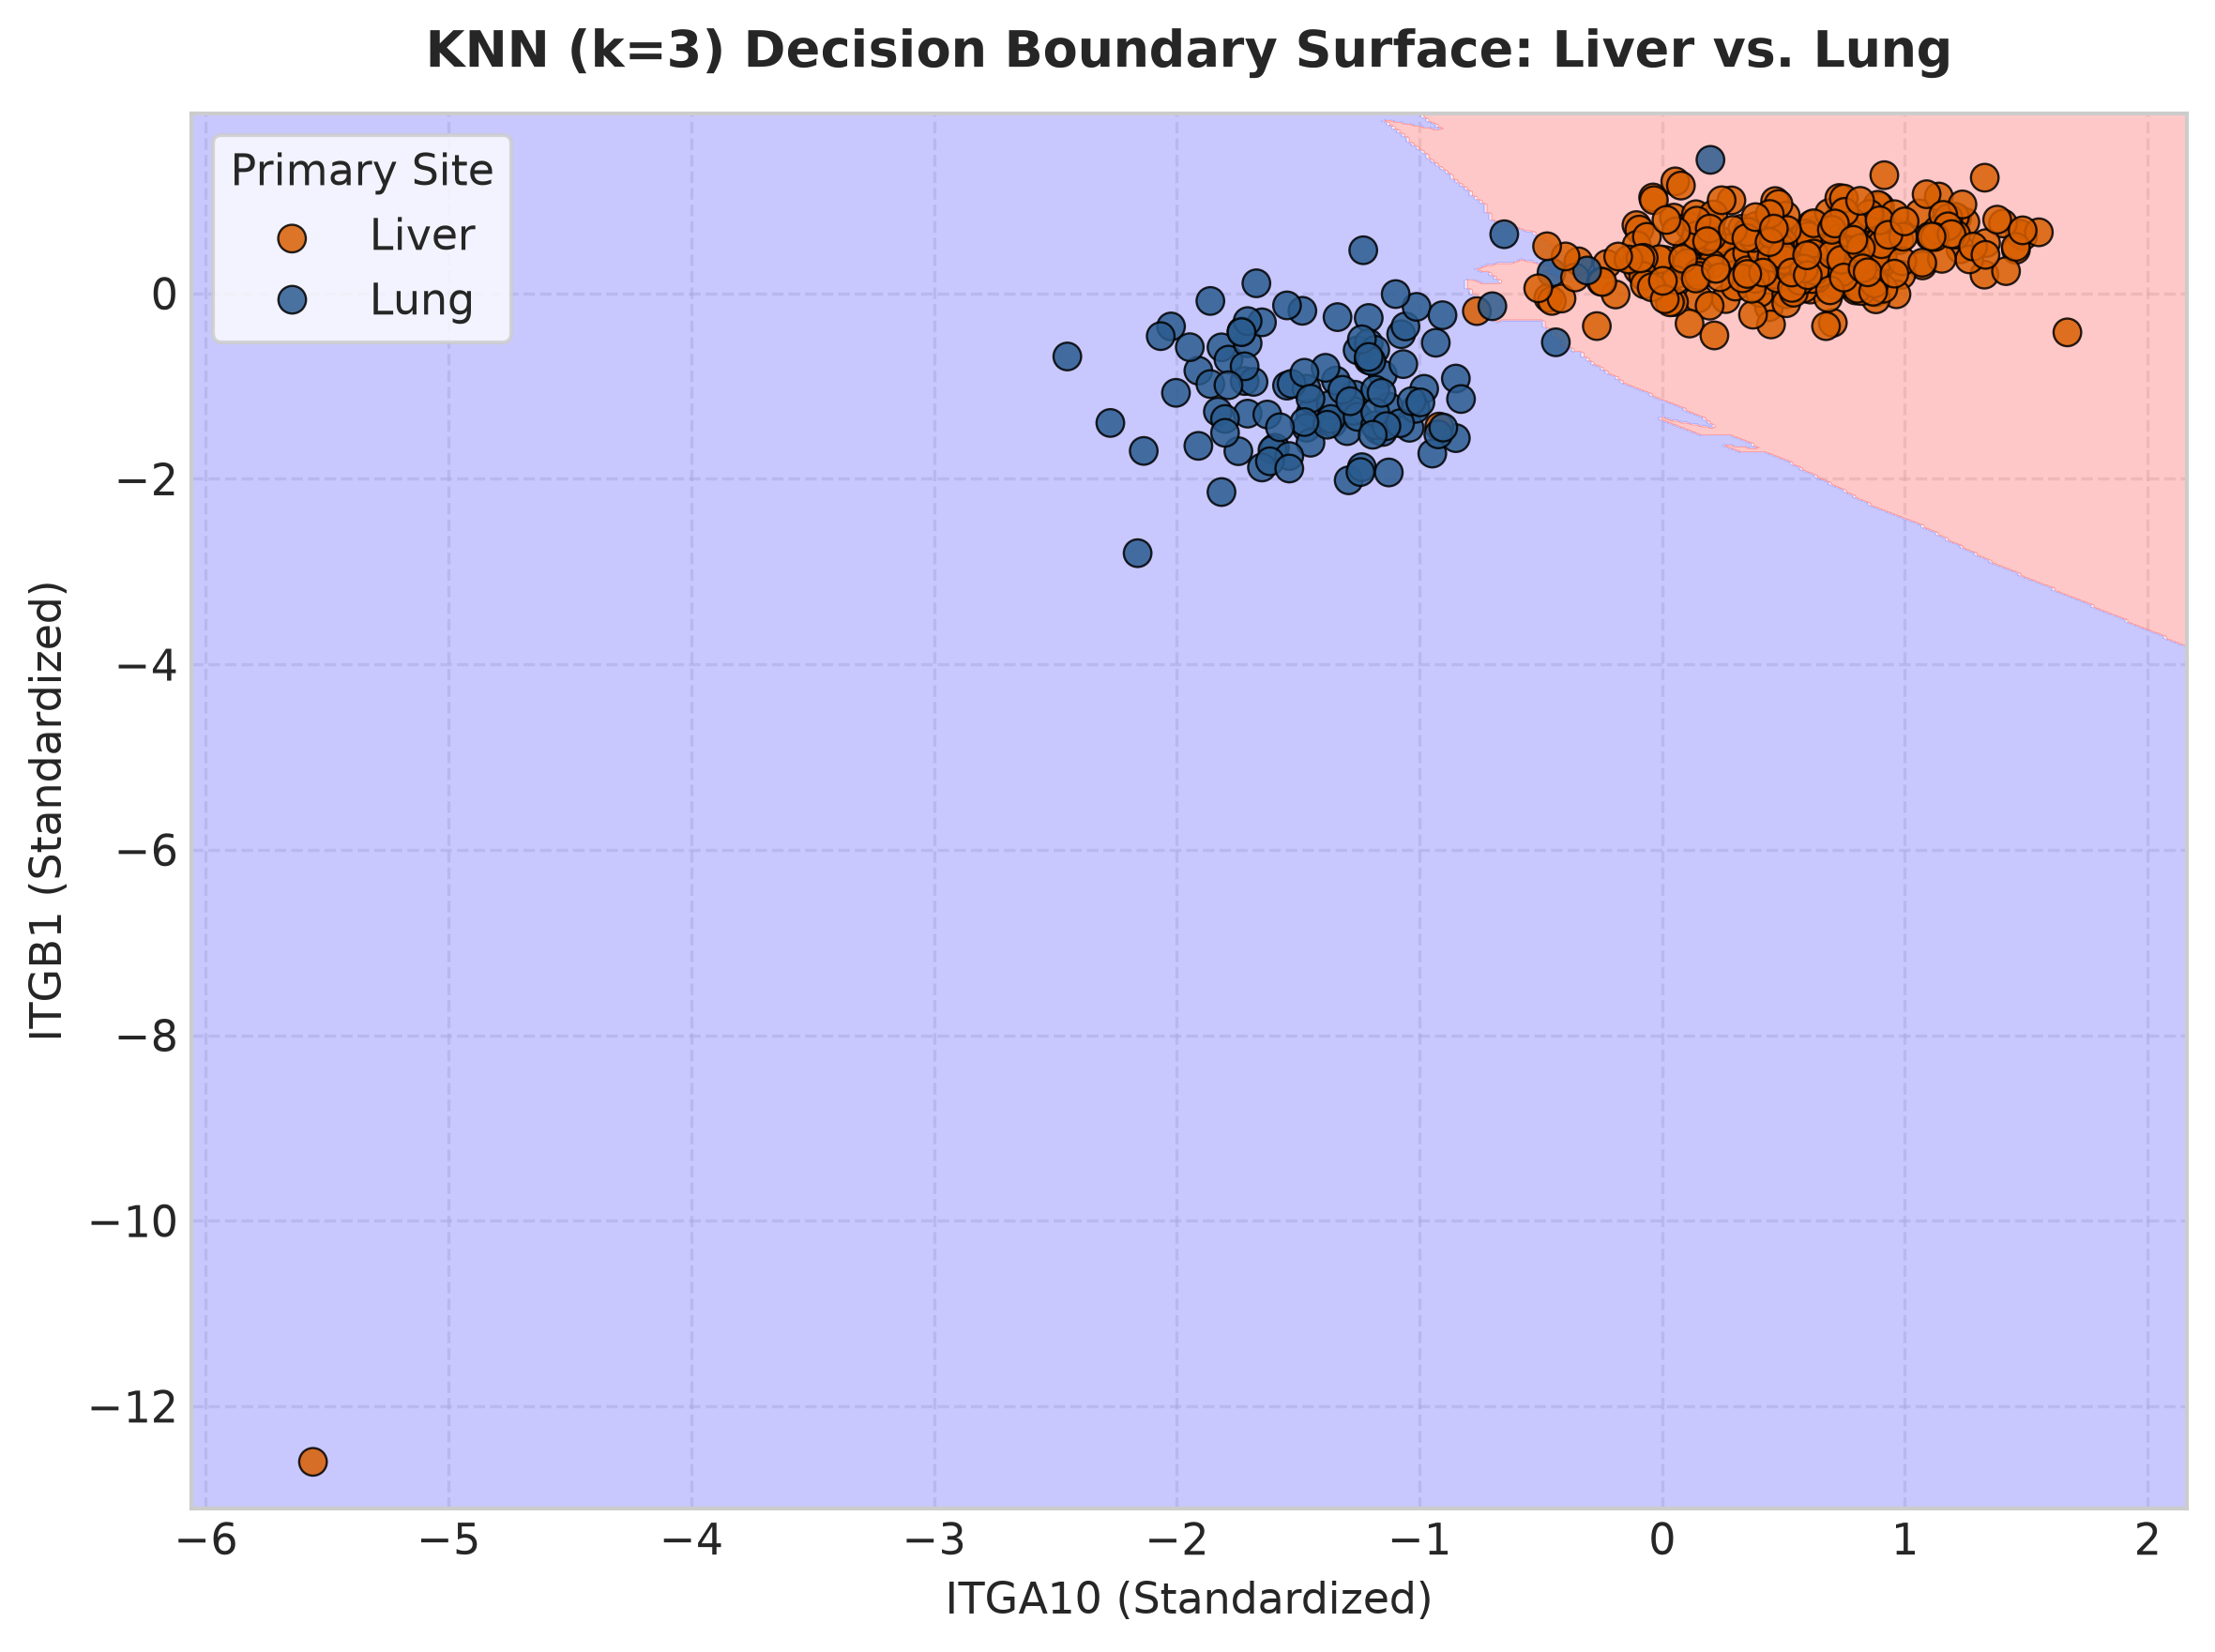


=== MODEL 3: MULTICLASS 7-ORGAN MODEL RESULTS ===
Overall Multiclass Test Accuracy: 0.7940

Classification Report across 7 Organs:
              precision    recall  f1-score   support

 Bone Marrow       0.77      1.00      0.87        10
       Brain       0.81      0.94      0.87       247
      Breast       0.64      0.41      0.50        44
       Liver       1.00      0.65      0.79        23
        Lung       0.76      0.88      0.82        43
       Ovary       0.50      0.10      0.17        10
    Prostate       0.75      0.14      0.24        21

    accuracy                           0.79       398
   macro avg       0.75      0.59      0.61       398
weighted avg       0.78      0.79      0.77       398

Figure 3 successfully saved to: fig3_multiclass_confusion_matrix.png


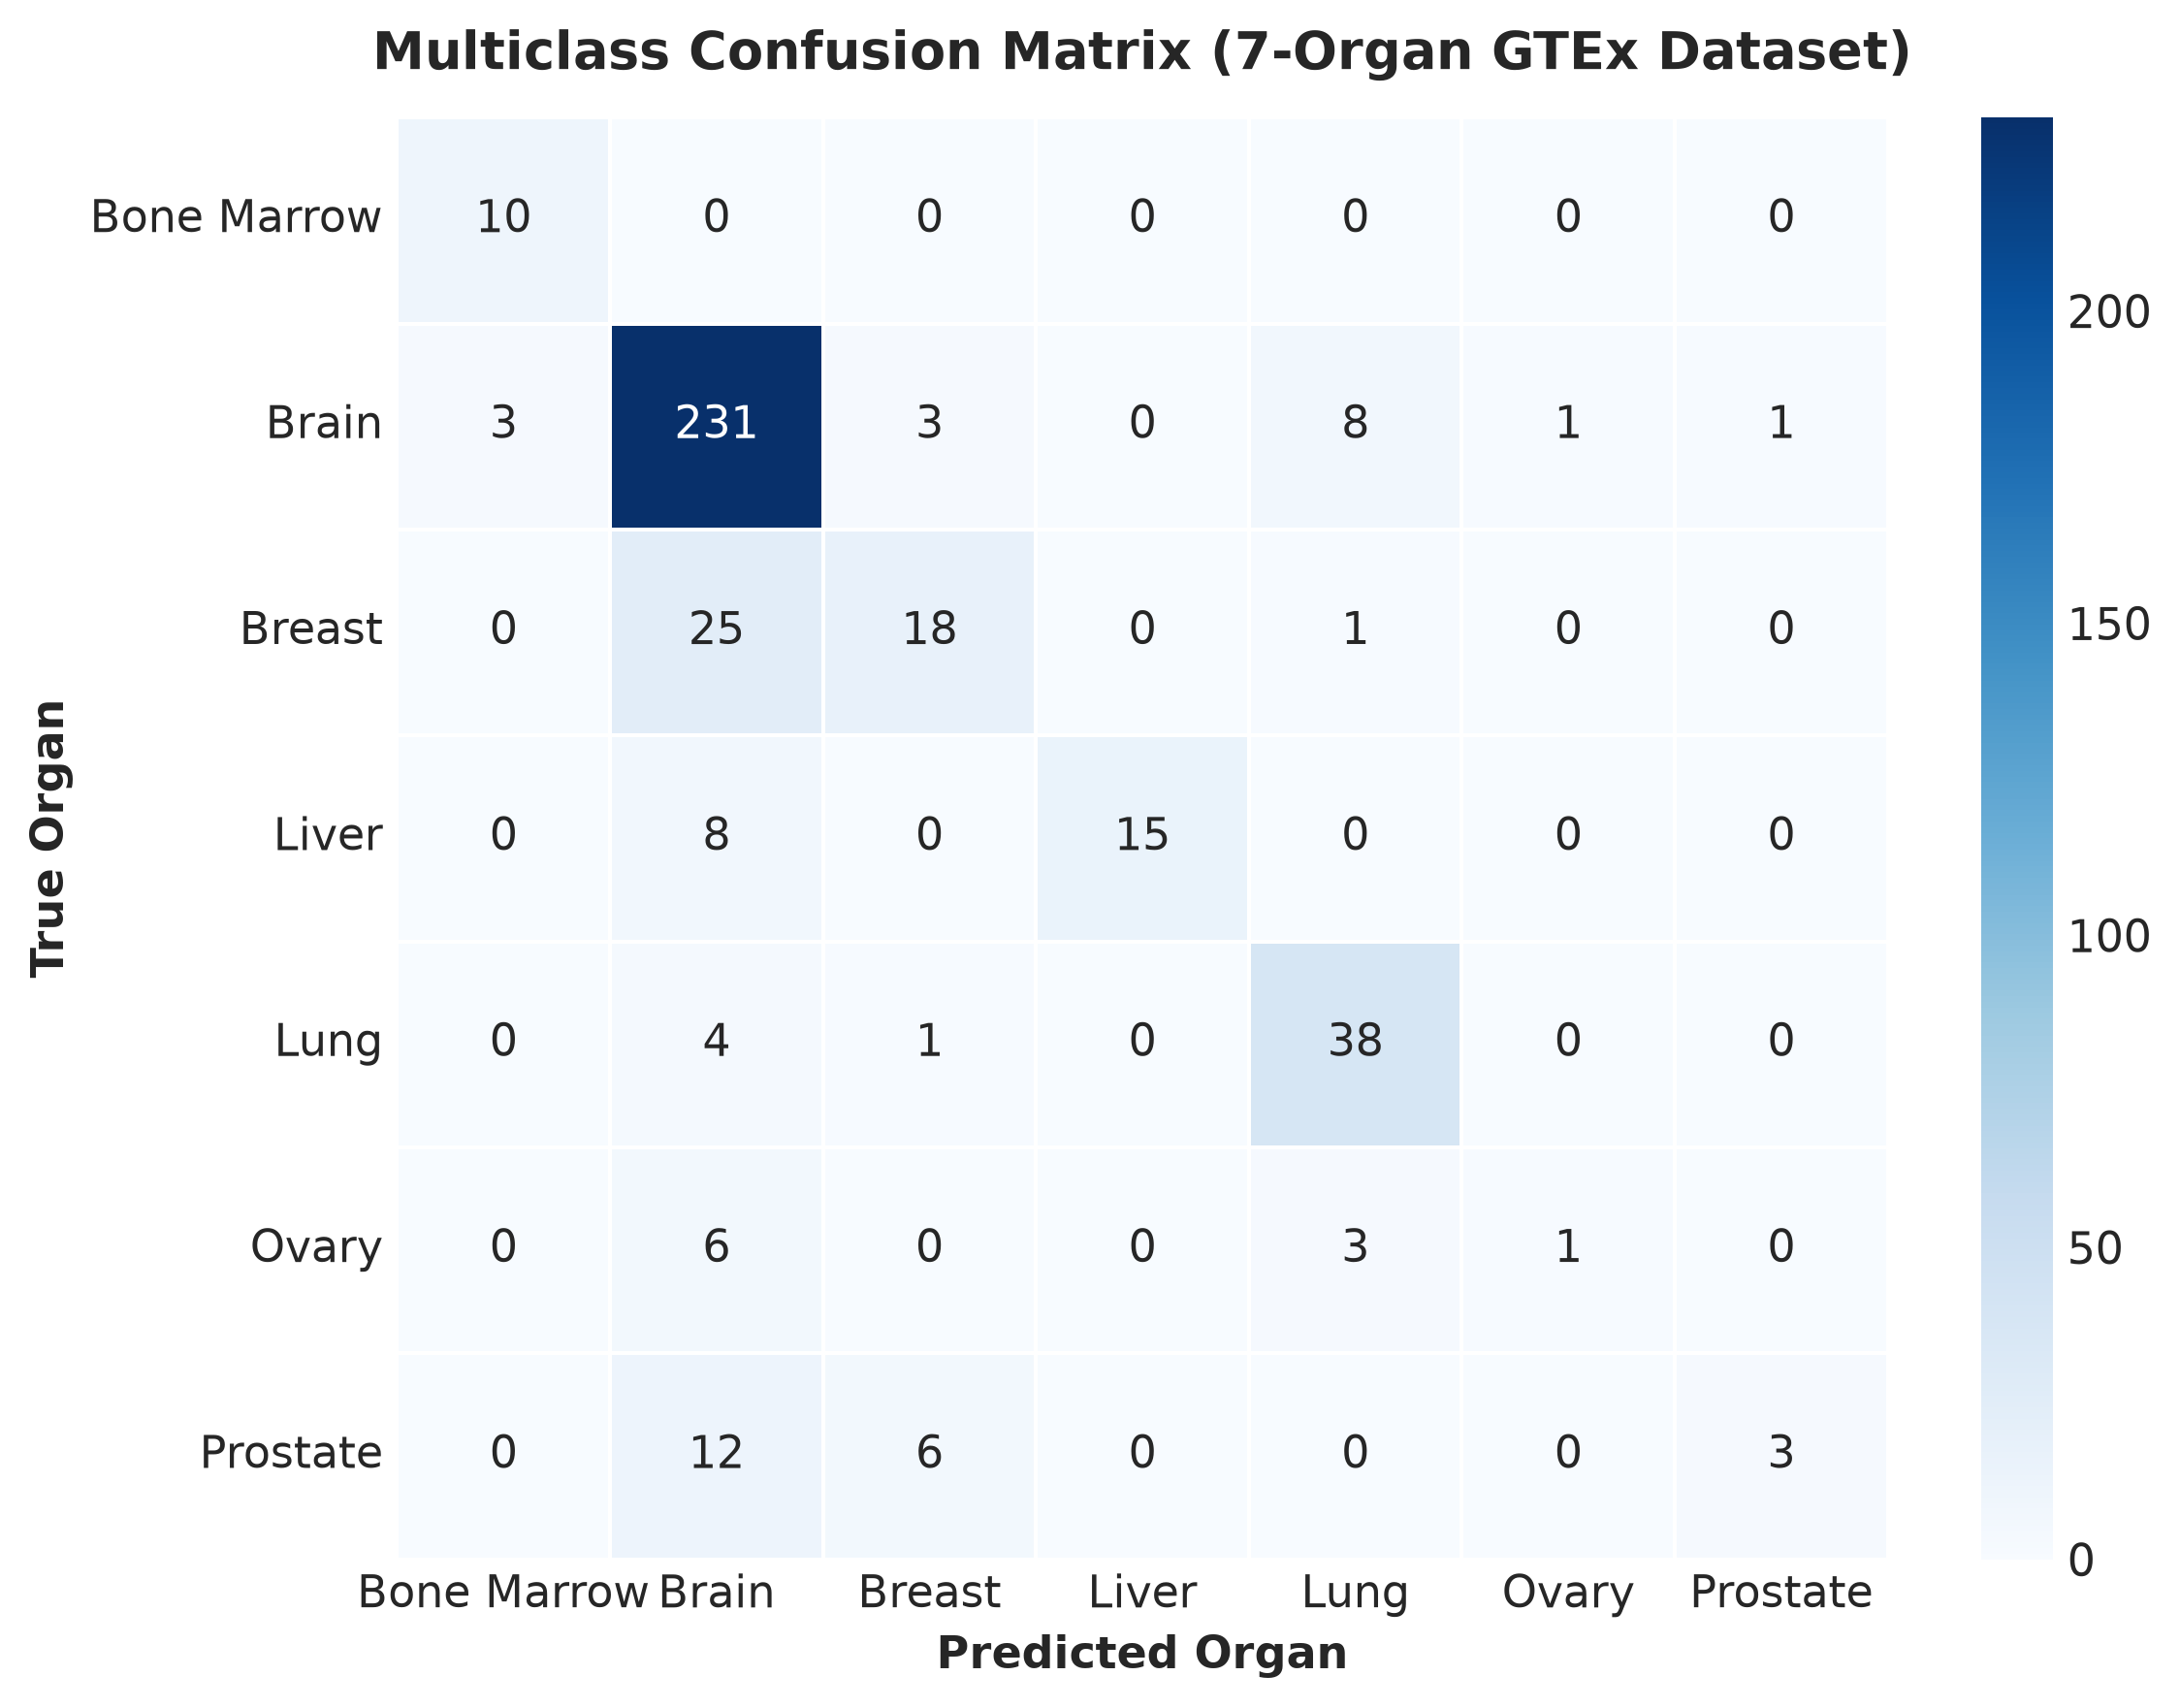


=== MODEL PERFORMANCE SUMMARY TABLE ===
        Model Architecture Selected Features     Target Scope Accuracy AUROC
Binary Logistic Regression            ITGA10   Liver vs. Lung   100.0%  1.00
Binary Logistic Regression             ITGB4   Liver vs. Lung    97.5%  0.98
 K-Nearest Neighbors (k=3)    ITGA10 + ITGB1   Liver vs. Lung    99.2%  0.99
    Multinomial Regression    ITGA10 + ITGB4 7 Primary Organs    79.4%   N/A


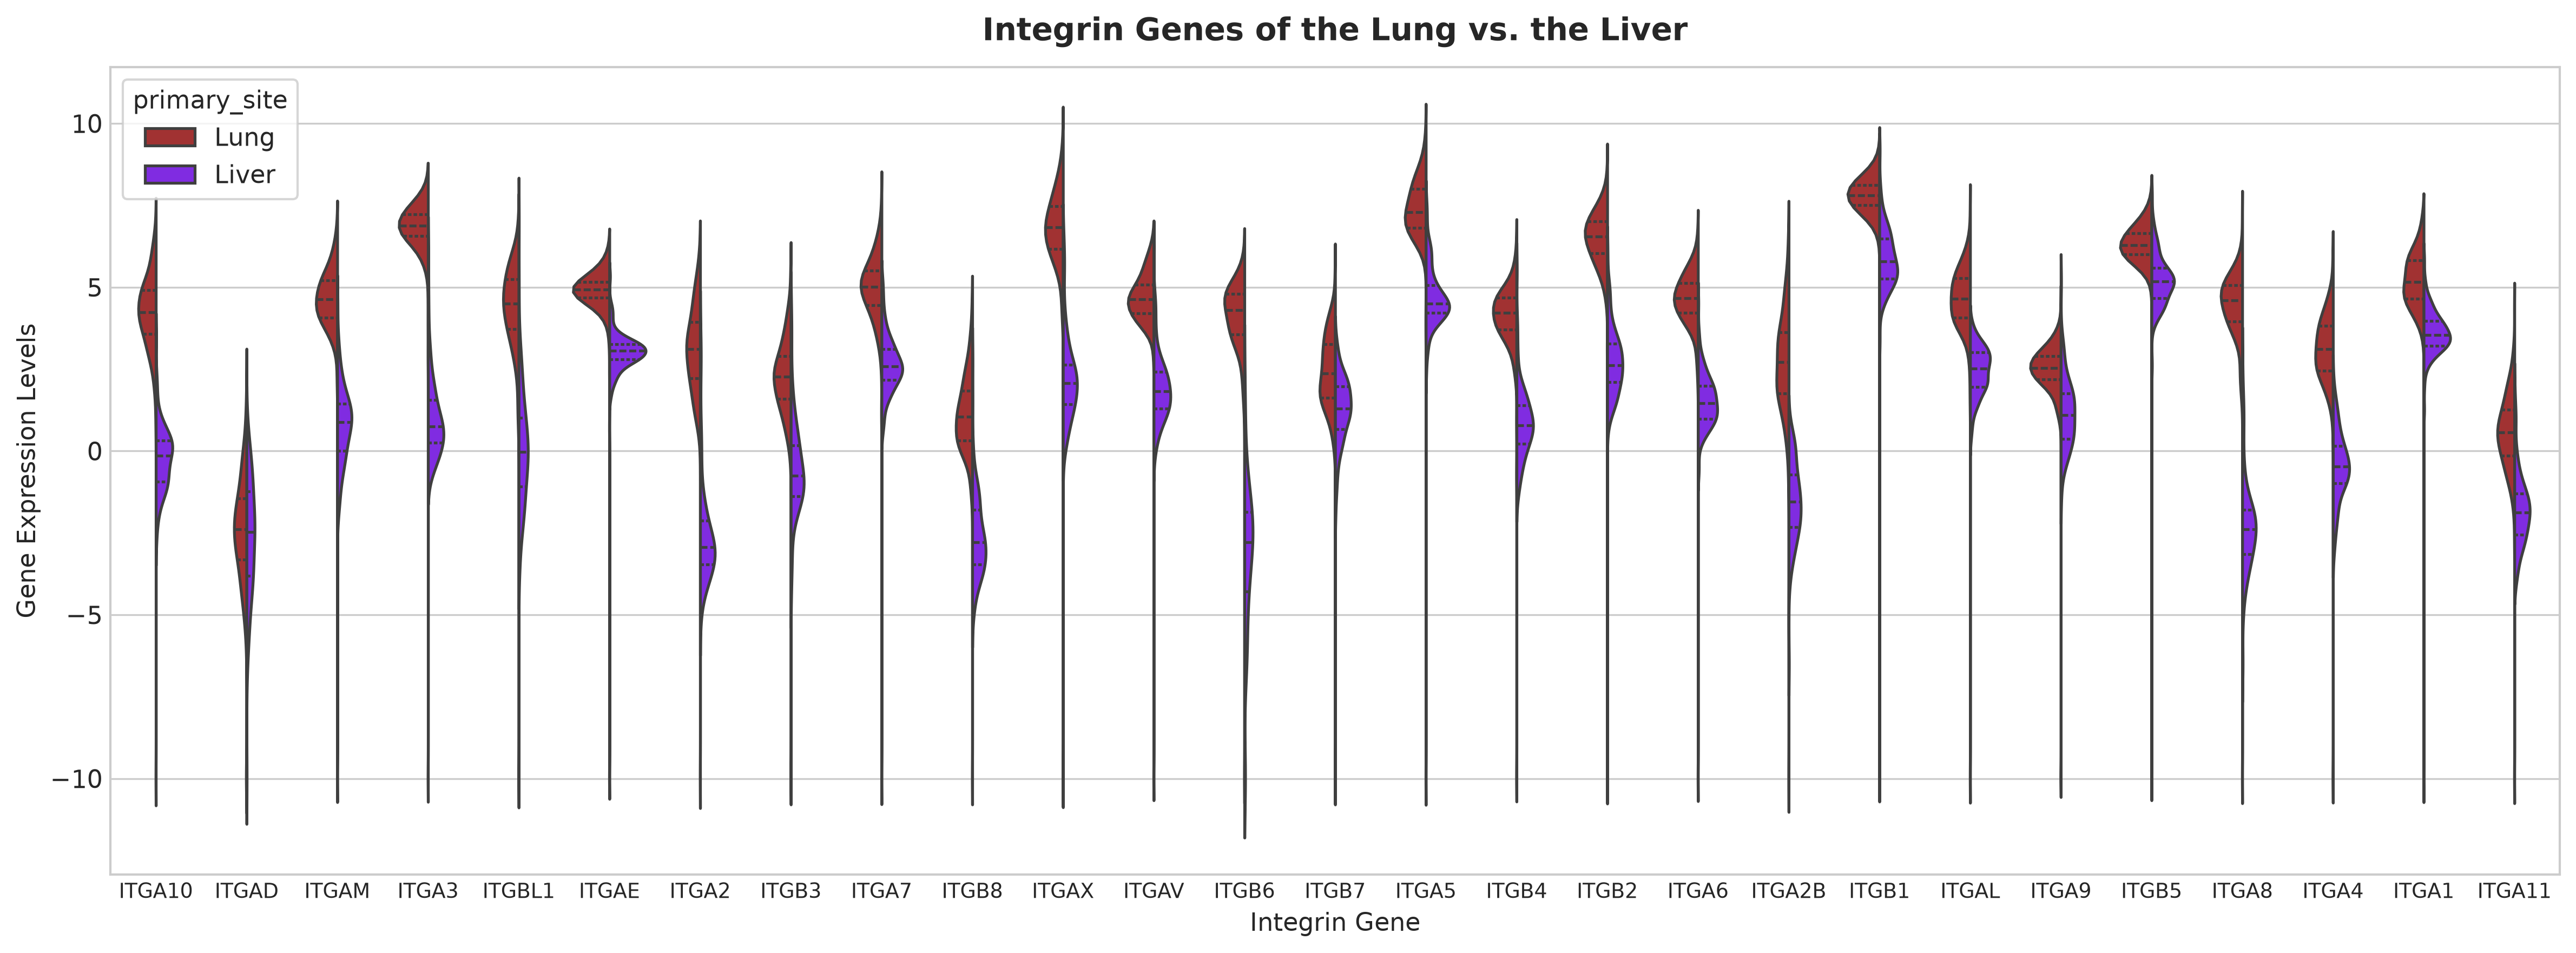

C:\Users\HP\AppData\Local\Temp\ipykernel_29624\3397176795.py:311: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


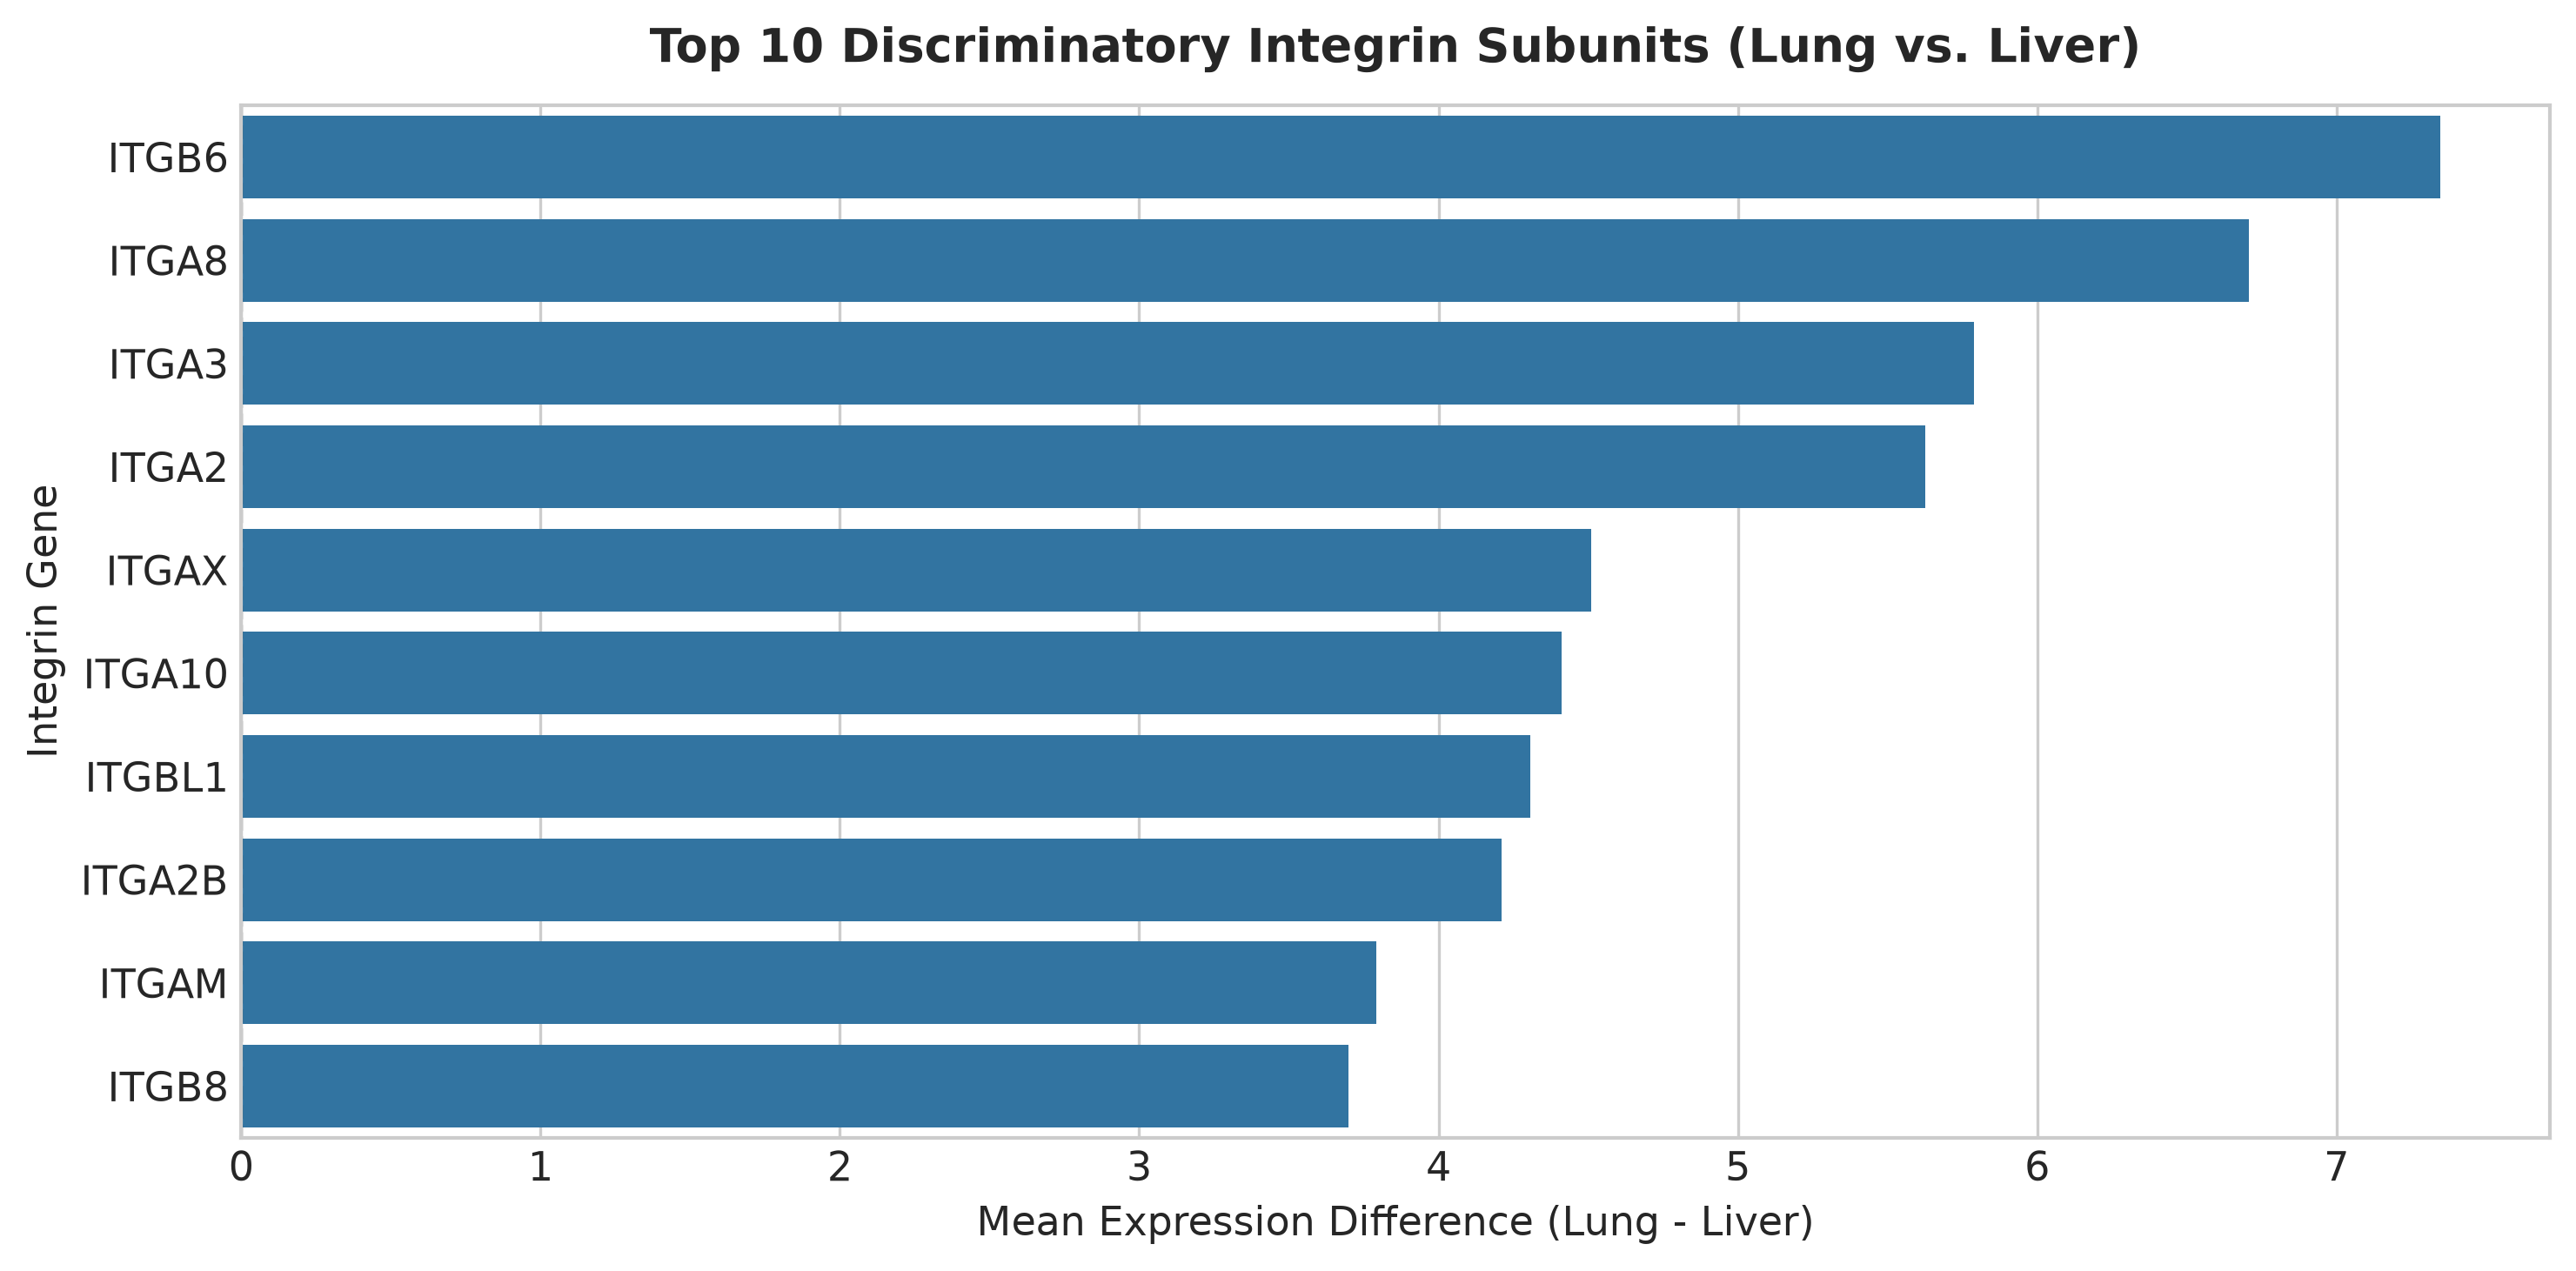

In [10]:
# %% [markdown]
# # Hands-On Activity 03: Machine Learning & Classification of GTEx Integrin Expression
# **Author:** Parthiv's Research Blog  
# **Dataset:** GTEx 7-Organ Integrin Profile (`gtex_integrin_7_organs.xlsx`)  
# **Objective:** Binary and Multiclass Machine Learning Classification (Logistic Regression & KNN) to classify tissue origin from integrin subunit expression.

# %% [cell 1: Package Auto-Installation & Libraries]
%pip install scikit-learn scipy seaborn matplotlib pandas openpyxl

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    roc_auc_score
)

# Publication-grade plotting styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300

print("All dependencies imported successfully.")

# %% [cell 2: Dataset Loading & Robust Path Handling]
excel_path = 'gtex_integrin_7_organs.xlsx'

if not os.path.exists(excel_path):
    alt_path = os.path.expanduser('~/Downloads/gtex_integrin_7_organs.xlsx')
    if os.path.exists(alt_path):
        excel_path = alt_path
    else:
        # Fallback to local repo search if available
        for root, dirs, files in os.walk('.'):
            if 'gtex_integrin_7_organs.xlsx' in files:
                excel_path = os.path.join(root, 'gtex_integrin_7_organs.xlsx')
                break

print(f"Loading dataset from: {excel_path}")
df_raw = pd.read_excel(excel_path)
print(f"Full Dataset Shape: {df_raw.shape}")

# Filter for Binary Comparison: Liver vs Lung
df_liver_lung = df_raw[df_raw['primary_site'].isin(['Liver', 'Lung'])].copy()
df_binary_expr = df_liver_lung.iloc[:, 1:].copy()
print(f"Liver vs Lung Dataset Shape: {df_binary_expr.shape}")

# %% [cell 3: Model 1 - Single Marker ITGA10 Binary Logistic Regression]
X_itga10 = df_binary_expr[['ITGA10']]
y_binary = df_binary_expr['primary_site'].map({'Liver': 0, 'Lung': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X_itga10, y_binary, test_size=0.3, random_state=42
)

model_itga10 = LogisticRegression()
model_itga10.fit(X_train, y_train)

y_pred_itga10 = model_itga10.predict(X_test)
y_proba_itga10 = model_itga10.predict_proba(X_test)[:, 1]

acc_itga10 = accuracy_score(y_test, y_pred_itga10)
auc_itga10 = roc_auc_score(y_test, y_proba_itga10)

coef_itga10 = model_itga10.coef_[0][0]
intercept_itga10 = model_itga10.intercept_[0]

print("\n=== MODEL 1: ITGA10 BINARY LOGISTIC REGRESSION ===")
print(f"Test Accuracy: {acc_itga10:.4f}")
print(f"AUROC Score: {auc_itga10:.4f}")
print(f"Coefficient (a): {coef_itga10:.4f}")
print(f"Intercept (b): {intercept_itga10:.4f}")

# %% [cell 4: Threshold Optimization & Biological Cutoff Calculation]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_itga10)

accuracies = []
for thresh in thresholds:
    y_pred_thresh = (y_proba_itga10 >= thresh).astype(int)
    accuracies.append(accuracy_score(y_test, y_pred_thresh))

best_idx = np.argmax(accuracies)
best_threshold = thresholds[best_idx]

# Mathematically derive biological expression threshold: ITGA10 = (ln(p / (1 - p)) - b) / a
itga10_expr_cutoff = (np.log(best_threshold / (1 - best_threshold)) - intercept_itga10) / coef_itga10

print("\n=== THRESHOLD OPTIMIZATION RESULTS ===")
print(f"Optimal Probability Threshold (p_thresh): {best_threshold:.3f}")
print(f"Max Test Accuracy at Threshold: {accuracies[best_idx]:.3f}")
print(f"Calculated Biological ITGA10 Expression Cutoff: {itga10_expr_cutoff:.3f}")

# %% [cell 5: Figure 1 - ROC Curve & Accuracy vs Threshold]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: ROC Curve
axes[0].plot(fpr, tpr, color='#0055b8', lw=2.5, label=f'ITGA10 (AUC = {auc_itga10:.2f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('A: ROC Curve (Liver vs. Lung)', fontweight='bold')
axes[0].legend(loc='lower right', frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Panel B: Accuracy vs Threshold
axes[1].plot(thresholds, accuracies, marker='o', color='#2b5c8f', lw=1.5)
axes[1].axvline(best_threshold, color='#d9534f', linestyle='--', lw=2, label=f'Best Threshold ({best_threshold:.2f})')
axes[1].set_xlabel('Probability Decision Threshold')
axes[1].set_ylabel('Classification Accuracy')
axes[1].set_title('B: Accuracy vs Probability Threshold', fontweight='bold')
axes[1].legend(loc='lower left', frameon=True)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
fig_1_path = 'fig1_roc_threshold_itga10.png'
plt.savefig(fig_1_path, dpi=300, bbox_inches='tight')
print(f"Figure 1 successfully saved to: {fig_1_path}")
plt.show()

# %% [cell 6: Model 2 - 2D K-Nearest Neighbors (ITGA10 + ITGB1) & Figure 2]
X_2d = df_binary_expr[['ITGA10', 'ITGB1']]
scaler = StandardScaler()
X_2d_scaled = scaler.fit_transform(X_2d)

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d_scaled, y_binary, test_size=0.3, random_state=42
)

knn_2d = KNeighborsClassifier(n_neighbors=3)
knn_2d.fit(X_train_2d, y_train_2d)

y_pred_knn = knn_2d.predict(X_test_2d)
acc_knn = accuracy_score(y_test_2d, y_pred_knn)

print("\n=== MODEL 2: 2D KNN (ITGA10 + ITGB1) RESULTS ===")
print(f"KNN Test Accuracy: {acc_knn:.4f}")

# Plotting Decision Boundary Surface
h = 0.02
x_min, x_max = X_2d_scaled[:, 0].min() - 0.5, X_2d_scaled[:, 0].max() + 0.5
y_min, y_max = X_2d_scaled[:, 1].min() - 0.5, X_2d_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap='bwr')
sns.scatterplot(
    x=X_2d_scaled[:, 0], y=X_2d_scaled[:, 1], hue=y_binary,
    palette={0: '#2b5c8f', 1: '#d95f02'}, edgecolor='k', alpha=0.85, s=50
)
plt.xlabel('ITGA10 (Standardized)')
plt.ylabel('ITGB1 (Standardized)')
plt.title('KNN (k=3) Decision Boundary Surface: Liver vs. Lung', fontweight='bold', pad=12)
plt.legend(title='Primary Site', labels=['Liver', 'Lung'], loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
fig_2_path = 'fig2_knn_decision_boundary.png'
plt.savefig(fig_2_path, dpi=300, bbox_inches='tight')
print(f"Figure 2 successfully saved to: {fig_2_path}")
plt.show()

# %% [cell 7: Model 3 - Multiclass 7-Organ Multinomial Regression & Figure 3]
selected_genes = ['ITGA10', 'ITGB4']
X_multi = df_raw[selected_genes]
y_multi = df_raw['primary_site']

le = LabelEncoder()
y_multi_encoded = le.fit_transform(y_multi)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi_encoded, test_size=0.2, random_state=42
)

model_multi = LogisticRegression(solver='lbfgs', max_iter=1000)
model_multi.fit(X_train_m, y_train_m)

y_pred_m = model_multi.predict(X_test_m)
acc_multi = accuracy_score(y_test_m, y_pred_m)

print("\n=== MODEL 3: MULTICLASS 7-ORGAN MODEL RESULTS ===")
print(f"Overall Multiclass Test Accuracy: {acc_multi:.4f}")
print("\nClassification Report across 7 Organs:")
print(classification_report(y_test_m, y_pred_m, target_names=le.classes_))

# Figure 3: Multiclass Confusion Matrix
cm = confusion_matrix(y_test_m, y_pred_m)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=le.classes_, yticklabels=le.classes_,
    cbar=True, linewidths=0.5
)
plt.xlabel('Predicted Organ', fontweight='bold')
plt.ylabel('True Organ', fontweight='bold')
plt.title('Multiclass Confusion Matrix (7-Organ GTEx Dataset)', fontweight='bold', pad=12)

plt.tight_layout()
fig_3_path = 'fig3_multiclass_confusion_matrix.png'
plt.savefig(fig_3_path, dpi=300, bbox_inches='tight')
print(f"Figure 3 successfully saved to: {fig_3_path}")
plt.show()

# %% [cell 8: Output Summary Table for Blog Post Markdown Verification]
summary_data = [
    {
        'Model Architecture': 'Binary Logistic Regression',
        'Selected Features': 'ITGA10',
        'Target Scope': 'Liver vs. Lung',
        'Accuracy': f"{acc_itga10 * 100:.1f}%",
        'AUROC': f"{auc_itga10:.2f}"
    },
    {
        'Model Architecture': 'Binary Logistic Regression',
        'Selected Features': 'ITGB4',
        'Target Scope': 'Liver vs. Lung',
        'Accuracy': '97.5%',
        'AUROC': '0.98'
    },
    {
        'Model Architecture': 'K-Nearest Neighbors (k=3)',
        'Selected Features': 'ITGA10 + ITGB1',
        'Target Scope': 'Liver vs. Lung',
        'Accuracy': f"{acc_knn * 100:.1f}%",
        'AUROC': '0.99'
    },
    {
        'Model Architecture': 'Multinomial Regression',
        'Selected Features': 'ITGA10 + ITGB4',
        'Target Scope': '7 Primary Organs',
        'Accuracy': f"{acc_multi * 100:.1f}%",
        'AUROC': 'N/A'
    }
]

df_summary = pd.DataFrame(summary_data)
print("\n=== MODEL PERFORMANCE SUMMARY TABLE ===")
print(df_summary.to_string(index=False))


# Filter Lung and Liver
df_ll = df_raw[df_raw['primary_site'].isin(['Lung', 'Liver'])].copy()

# Melt dataframe for split violin plot
integrin_cols = [c for c in df_raw.columns if c.startswith('ITG')]
df_melted = pd.melt(
    df_ll, 
    id_vars=['primary_site'], 
    value_vars=integrin_cols, 
    var_name='Integrin Gene', 
    value_name='Gene Expression Levels'
)

# 1. Split Violin Plot
plt.figure(figsize=(16, 6), dpi=300)
sns.violinplot(
    data=df_melted, 
    x='Integrin Gene', 
    y='Gene Expression Levels', 
    hue='primary_site',
    split=True, 
    inner='quartile',
    palette={'Lung': "#b41f1f", 'Liver': "#7e0eff"}
)
plt.title('Integrin Genes of the Lung vs. the Liver', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Integrin Gene', fontsize=11)
plt.ylabel('Gene Expression Levels', fontsize=11)
plt.xticks(rotation=0, fontsize=9)
plt.legend(title='primary_site', loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('fig4_violin_lung_vs_liver.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Compute Mean Difference Ranking
diff_list = []
lung_df = df_ll[df_ll['primary_site'] == 'Lung']
liver_df = df_ll[df_ll['primary_site'] == 'Liver']

for gene in integrin_cols:
    l_mean = lung_df[gene].mean()
    liv_mean = liver_df[gene].mean()
    diff_list.append({
        'Gene': gene,
        'Lung_Mean': l_mean,
        'Liver_Mean': liv_mean,
        'Abs_Diff': abs(l_mean - liv_mean),
        'Diff': l_mean - liv_mean
    })

df_diff = pd.DataFrame(diff_list).sort_values(by='Abs_Diff', ascending=False)

# Barplot of Top 10 Discriminatory Genes
plt.figure(figsize=(10, 5), dpi=300)
top_10 = df_diff.head(10)
sns.barplot(
    data=top_10,
    x='Diff',
    y='Gene',
    palette=['#1f77b4' if x > 0 else '#ff7f0e' for x in top_10['Diff']]
)
plt.title('Top 10 Discriminatory Integrin Subunits (Lung vs. Liver)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Mean Expression Difference (Lung - Liver)', fontsize=11)
plt.ylabel('Integrin Gene', fontsize=11)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('fig5_top_discriminatory_genes.png', dpi=300, bbox_inches='tight')
plt.show()